# Object detection — a runnable, measured build

Image *classification* answers **what** is in a picture; **object detection** answers **what, where, and how many** — a class *and* a bounding box for every object in the scene. This notebook builds detection's three load-bearing ideas **from scratch** and checks each against a trusted reference, then runs a **real** pretrained detector on a **real** photograph and measures everything:

- **IoU** (Intersection over Union) — the box-overlap metric — checked against `torchvision.ops.box_iou`.
- **NMS** (Non-Maximum Suppression) — the duplicate-removal step — checked against `torchvision.ops.nms` on the *real* overlapping boxes the detector emits.
- **AP** (Average Precision) — the detection score — pinned to a hand-verified worked example (AP = 11/12), then applied to the real detections.

It imports the **exact same functions** as the companion page and its figures (from `object_detection.py`), so the numbers here are the numbers there. Everything is **CPU-pinned and seeded** for a reproducible trace. If the COCO image can't be downloaded, the module falls back to a real bundled photo (Grace Hopper) — the detector still runs on a real image and every check still executes.

> Companion page: **Object Detection**. Run top-to-bottom (Kernel → Restart & Run All). The detector weights download once (~160 MB) to a temp cache, never into the repo.

## Step 0 — Setup: import the real module and print versions

We import the pipeline from the chapter module so this notebook runs the *same code* the page and figures use, and print the library versions + the accelerator we detected (we still run on CPU on purpose — GPU kernels are nondeterministic and every number here must be bit-reproducible).

In [1]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import object_detection as od

print(f'torch {torch.__version__} | torchvision {torchvision.__version__} | numpy {np.__version__}')
print(f'accelerator available: {od.detect_accelerator()}  (reported metrics are CPU-pinned, seed={od.SEED})')

torch 2.12.0 | torchvision 0.27.0 | numpy 2.4.6
accelerator available: mps  (reported metrics are CPU-pinned, seed=0)


## Step 1 — A box is four numbers — but *which* four? (formats)

Every box has four numbers, but three conventions are in daily use and silently mixing them is the #1 detection bug:

- **xyxy** = $(x_{min}, y_{min}, x_{max}, y_{max})$ — corners; what IoU, NMS, and drawing want.
- **xywh** = $(x_{min}, y_{min}, w, h)$ — top-left + size; the COCO annotation format.
- **cxcywh** = $(x_{center}, y_{center}, w, h)$ — center + size; what anchor regression predicts.

We implement the conversions and check them against `torchvision.ops.box_convert` (and that a round-trip is lossless).

In [2]:
fc = od.verify_box_formats()
print(f'max|xywh   - torchvision| = {fc.max_err_xywh:.1e}')
print(f'max|cxcywh - torchvision| = {fc.max_err_cxcywh:.1e}')
print(f'xyxy -> cxcywh -> xyxy round-trip error = {fc.max_err_roundtrip:.1e}')
box = np.array([[10., 20., 110., 220.]])
print(f'\nexample: xyxy {box[0].tolist()}  ->  xywh {od.xyxy_to_xywh(box)[0].tolist()}  '
      f'->  cxcywh {od.xyxy_to_cxcywh(box)[0].tolist()}')
assert fc.max_err_cxcywh < 1e-9
print('OK: our conversions match torchvision')

max|xywh   - torchvision| = 0.0e+00
max|cxcywh - torchvision| = 0.0e+00
xyxy -> cxcywh -> xyxy round-trip error = 1.4e-14

example: xyxy [10.0, 20.0, 110.0, 220.0]  ->  xywh [10.0, 20.0, 100.0, 200.0]  ->  cxcywh [60.0, 120.0, 100.0, 200.0]
OK: our conversions match torchvision


## Step 2 — IoU: how much do two boxes overlap?

**Intersection over Union** is the overlap metric everything downstream uses:

$$\mathrm{IoU}(A, B) = \frac{\mathrm{area}(A \cap B)}{\mathrm{area}(A \cup B)}.$$

The intersection rectangle is `[max of the mins, min of the maxes]`, clamped so no overlap gives 0; the union is `area(A) + area(B) − intersection`. IoU is 0 for disjoint boxes and 1 for identical boxes. We implement a vectorized IoU *matrix* (every A against every B) and check it against `torchvision.ops.box_iou`.

In [3]:
iou = od.verify_iou()
print(f'max|IoU - torchvision.ops.box_iou| = {iou.max_err_vs_torchvision:.2e}')
# a hand-checkable pair: two 10x10 boxes shifted by 5 in x -> intersection 5x10=50, union 150 -> 1/3
a = np.array([[0., 0., 10., 10.]])
b = np.array([[5., 0., 15., 10.]])
print(f'IoU(two 10x10 boxes shifted 5px) = {od.box_iou_from_scratch(a, b)[0,0]:.4f}  (= 50/150 = 0.3333)')
assert iou.max_err_vs_torchvision < 1e-6
print('OK: our IoU IS torchvision IoU')

max|IoU - torchvision.ops.box_iou| = 0.00e+00
IoU(two 10x10 boxes shifted 5px) = 0.3333  (= 50/150 = 0.3333)
OK: our IoU IS torchvision IoU


## Step 3 — NMS: keep one box per object

A detector fires many overlapping boxes on the same object. **Non-Maximum Suppression** removes the duplicates greedily: sort boxes by score; take the top one, keep it, and discard every remaining box whose IoU with it exceeds a threshold (they're duplicates of the same object); repeat. We implement it and check it against `torchvision.ops.nms` on a small set of overlapping boxes (identical kept indices).

In [4]:
boxes = np.array([[10.,10,110,110],[14,12,112,108],[200,200,300,300],[8,14,105,112],[205,198,298,305]])
scores = np.array([0.9, 0.82, 0.75, 0.60, 0.55])
kept = od.nms_from_scratch(boxes, scores, iou_thresh=0.5)
print(f'{len(boxes)} boxes -> NMS keeps indices {kept.tolist()} (the two distinct objects, best score each)')
chk = od.verify_nms(boxes, scores, 0.5)
print(f'kept indices == torchvision.ops.nms: {chk.matches_torchvision}')
assert chk.matches_torchvision
print('OK: our NMS IS torchvision NMS')

5 boxes -> NMS keeps indices [0, 2] (the two distinct objects, best score each)
kept indices == torchvision.ops.nms: True
OK: our NMS IS torchvision NMS


## Step 4 — Anchors + box regression: predicting a box as a *correction*

Detectors don't predict box coordinates directly. They start from **anchors** (reference boxes tiled over the image) and predict a *correction* $(t_x, t_y, t_w, t_h)$ that nudges an anchor onto the object (Faster R-CNN):

$$t_x = \frac{g_x - a_x}{a_w},\ t_y = \frac{g_y - a_y}{a_h},\ t_w = \log\frac{g_w}{a_w},\ t_h = \log\frac{g_h}{a_h}.$$

Centers shift in units of the anchor's size (scale-invariant); sizes are predicted in log-space (so a box can never go negative). If our encode/decode is a true inverse, `decode(encode(gt, anchor), anchor) == gt`.

In [5]:
rc = od.verify_box_regression()
print(f'max|decode(encode(gt)) - gt| = {rc.max_roundtrip_err:.1e}')
anchor = np.array([[50., 50., 150., 150.]])
gt = np.array([[60., 70., 170., 180.]])
delta = od.encode_boxes(gt, anchor)
print(f'encode -> (tx,ty,tw,th) = {tuple(round(float(v),3) for v in delta[0])}')
print(f'decode -> {od.decode_boxes(delta, anchor)[0].round(2).tolist()}  (recovers gt {gt[0].tolist()})')
assert rc.max_roundtrip_err < 1e-9
print('OK: the (tx,ty,tw,th) parametrization is an exact inverse')

max|decode(encode(gt)) - gt| = 1.4e-14
encode -> (tx,ty,tw,th) = (0.15, 0.25, 0.095, 0.095)
decode -> [60.0, 70.0, 170.0, 180.0]  (recovers gt [60.0, 70.0, 170.0, 180.0])
OK: the (tx,ty,tw,th) parametrization is an exact inverse


## Step 5 — Load a real photograph

Detection only means something on a real, multi-object scene. We load a real COCO photo (two cats on a couch with two remotes). If the download is unavailable, the module falls back to a real bundled photo so the notebook still runs on a real image.

image  : cats & remotes (COCO val2017)   [coco-download]
shape  : (480, 640, 3)  (H, W, 3 uint8)
ground-truth classes (hand-specified for scoring): ['cat', 'remote']


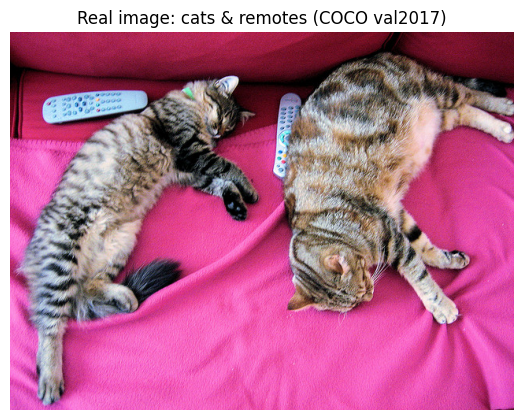

In [6]:
image = od.load_real_image()
print(f'image  : {image.name}   [{image.source}]')
print(f'shape  : {image.array.shape}  (H, W, 3 uint8)')
print(f'ground-truth classes (hand-specified for scoring): {list(image.ground_truth)}')
plt.figure(figsize=(6.5, 5))
plt.imshow(image.array)
plt.axis('off')
plt.title(f'Real image: {image.name}')
plt.show()

## Step 6 — Run a real pretrained detector

We load **Faster R-CNN (ResNet-50 FPN)** with COCO weights — a real two-stage detector — and run it on the image. It returns, for each detection, a **box**, a **class label** (one of 80 COCO categories), and a **score**. We keep detections scoring ≥ 0.5 and draw them. (Weights download once to a temp cache.)

  cat        0.989
  remote     0.979
  cat        0.953
  remote     0.781
  couch      0.541
  couch      0.540
  bed        0.538


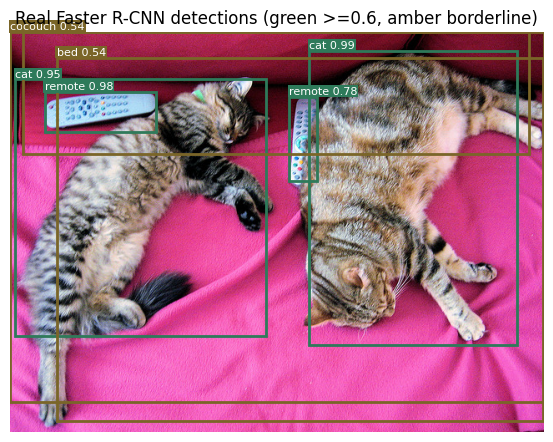

In [7]:
model, categories = od.load_detector(score_thresh=0.5, nms_thresh=0.5)
det = od.run_detector(model, categories, image.array)
for name, score in sorted(zip(det.names, det.scores), key=lambda t: -t[1]):
    print(f'  {name:10s} {score:.3f}')

fig, ax = plt.subplots(figsize=(7, 5.2))
ax.imshow(image.array)
ax.axis('off')
for bx, nm, sc in zip(det.boxes, det.names, det.scores):
    c = '#2E7A5A' if sc >= 0.6 else '#7A6528'
    ax.add_patch(mpatches.Rectangle((bx[0],bx[1]), bx[2]-bx[0], bx[3]-bx[1], fill=False, edgecolor=c, lw=2))
    ax.text(bx[0], bx[1]-3, f'{nm} {sc:.2f}', color='white', fontsize=8,
            bbox=dict(boxstyle='square,pad=0.1', fc=c, ec='none'))
ax.set_title('Real Faster R-CNN detections (green >=0.6, amber borderline)')
plt.show()

## Step 7 — Peek *before* NMS: the raw overlapping flood

The clean result above already had NMS applied inside the detector. To *see* what NMS does, we re-run the detector with its own NMS effectively disabled (`nms_thresh = 0.95`) and a low score threshold, then take all boxes of one class. A single object attracts **many** overlapping boxes — the raw material NMS cleans up.

In [8]:
raw_model, _ = od.load_detector(score_thresh=0.05, nms_thresh=0.95)
det_raw = od.run_detector(raw_model, categories, image.array)
cls = od._pick_nms_class(det_raw, image.ground_truth)
mask = np.array([n == cls for n in det_raw.names]) & (det_raw.scores >= 0.30)
raw_boxes, raw_scores = det_raw.boxes[mask], det_raw.scores[mask]
print(f"class '{cls}': {len(raw_boxes)} raw overlapping boxes (score >= 0.30) before NMS")

class 'cat': 44 raw overlapping boxes (score >= 0.30) before NMS


## Step 8 — Apply NMS to the real boxes (and verify against torchvision)

Now run our from-scratch NMS on those real overlapping boxes: the raw flood collapses to one box per real object. We confirm our kept indices are *identical* to `torchvision.ops.nms`, then draw before/after.

44 raw boxes -> 2 kept   (kept == torchvision.ops.nms: True)


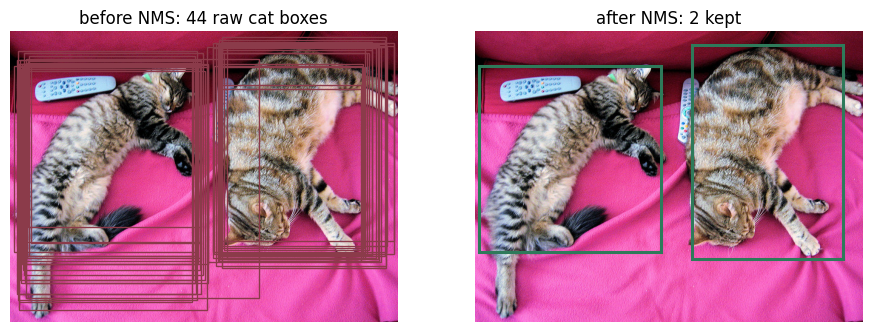

In [9]:
chk = od.verify_nms(raw_boxes, raw_scores, 0.5)
kept = od.nms_from_scratch(raw_boxes, raw_scores, 0.5)
print(f'{len(raw_boxes)} raw boxes -> {len(kept)} kept   (kept == torchvision.ops.nms: {chk.matches_torchvision})')
assert chk.matches_torchvision and len(kept) < len(raw_boxes)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.6))
for ax in (a1, a2):
    ax.imshow(image.array)
    ax.axis('off')
for bx in raw_boxes:
    a1.add_patch(mpatches.Rectangle((bx[0],bx[1]), bx[2]-bx[0], bx[3]-bx[1], fill=False, edgecolor='#8B3B4A', lw=1))
a1.set_title(f'before NMS: {len(raw_boxes)} raw {cls} boxes')
for i in kept:
    bx = raw_boxes[i]
    a2.add_patch(mpatches.Rectangle((bx[0],bx[1]), bx[2]-bx[0], bx[3]-bx[1], fill=False, edgecolor='#2E7A5A', lw=2.2))
a2.set_title(f'after NMS: {len(kept)} kept')
plt.show()

## Step 9 — Average Precision, from a worked example (AP = 11/12)

A detector needs a single score. **Average Precision** is the area under the **precision-recall curve**. Walking the detections from highest score to lowest, each is a **true positive** (matches an unclaimed ground-truth box at IoU ≥ 0.5) or a **false positive**; precision = TP/(TP+FP) and recall = TP/#GT are accumulated down the list, and AP integrates the (interpolated) curve.

To pin the implementation, here is a hand-verifiable case: 3 ground-truth boxes and 5 detections whose match sequence is **TP, TP, FP, TP, FP**. By hand, AP = 1/3 + 1/3 + 1/4 = **11/12 ≈ 0.9167**. Our code must reproduce that exactly.

AP (from scratch) = 0.916667   expected 11/12 = 0.916667


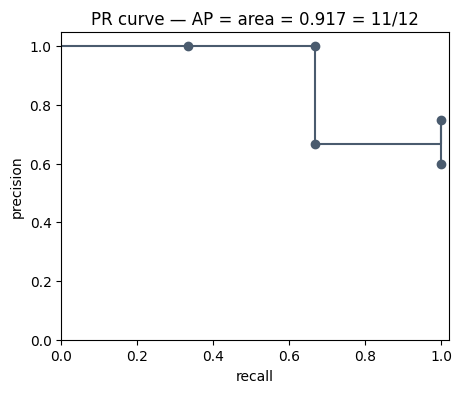

OK: AP reproduces the hand-verified worked example


In [10]:
kc = od.verify_ap_known_case()
print(f'AP (from scratch) = {kc.ap_measured:.6f}   expected 11/12 = {kc.ap_expected:.6f}')
assert abs(kc.ap_measured - 11/12) < 1e-9
c = kc.curve
plt.figure(figsize=(5, 4))
plt.step(np.concatenate(([0], c.recall)), np.concatenate(([1], c.precision)), where='post', color='#4A5B6E')
plt.scatter(c.recall, c.precision, color='#4A5B6E', zorder=3)
plt.xlabel('recall')
plt.ylabel('precision')
plt.ylim(0, 1.05)
plt.xlim(0, 1.02)
plt.title(f'PR curve — AP = area = {kc.ap_measured:.3f} = 11/12')
plt.show()
print('OK: AP reproduces the hand-verified worked example')

## Step 10 — AP on the real detections: why NMS matters for the *score*

NMS isn't cosmetic — it changes the score. Take the *same* real detections for one class and compute AP two ways: **before NMS** (the duplicate boxes each become a false positive, crushing precision) and **after NMS** (one clean box per object). NMS *raises* AP by removing duplicate false positives.

pre-NMS :  58 detections -> AP@0.5 = 0.6667
post-NMS:   6 detections -> AP@0.5 = 1.0000   (NMS lifts AP by +0.3333)


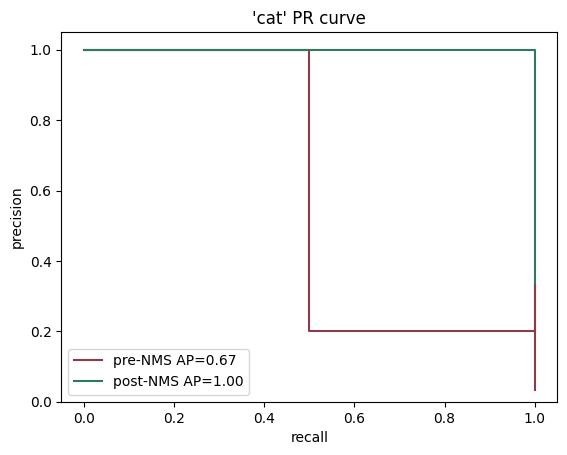

In [11]:
eval_model, _ = od.load_detector(score_thresh=0.05, nms_thresh=0.5)   # standard eval: post-NMS, low score
det_eval = od.run_detector(eval_model, categories, image.array)
gt = image.ground_truth[cls]
pre_mask = np.array([n == cls for n in det_raw.names])
post_mask = np.array([n == cls for n in det_eval.names])
pre = od.average_precision(det_raw.boxes[pre_mask], det_raw.scores[pre_mask], gt, 0.5)
post = od.average_precision(det_eval.boxes[post_mask], det_eval.scores[post_mask], gt, 0.5)
print(f'pre-NMS : {pre.n_det:3d} detections -> AP@0.5 = {pre.ap:.4f}')
print(f'post-NMS: {post.n_det:3d} detections -> AP@0.5 = {post.ap:.4f}   (NMS lifts AP by {post.ap-pre.ap:+.4f})')
for prc, col, lab in [(pre,'#8B3B4A','pre-NMS'),(post,'#2E7A5A','post-NMS')]:
    plt.step(np.concatenate(([0],prc.recall)), np.concatenate(([1],prc.precision)), where='post',
             color=col, label=f'{lab} AP={prc.ap:.2f}')
plt.xlabel('recall')
plt.ylabel('precision')
plt.legend()
plt.ylim(0, 1.05)
plt.title(f"'{cls}' PR curve")
plt.show()
assert post.ap >= pre.ap

## Step 11 — mAP and the COCO mAP@[.5:.95] sweep

**mAP** (mean Average Precision) averages AP over classes. The looser **AP@0.5** only asks for IoU ≥ 0.5; the headline **COCO mAP@[.5:.95]** averages AP over ten IoU thresholds from 0.50 to 0.95, so it rewards *tight* localization, not just detection — which is why it is always lower. On this single easy image the detector is excellent, so the numbers are high; a single image is illustrative, **not a benchmark**.

In [12]:
sweep = od.COCO_IOU_SWEEP
for name, gt_boxes in image.ground_truth.items():
    m = np.array([n == name for n in det_eval.names])
    ap50 = od.average_precision(det_eval.boxes[m], det_eval.scores[m], gt_boxes, 0.5).ap
    apco = od.mean_ap_over_iou(det_eval.boxes[m], det_eval.scores[m], gt_boxes, sweep)
    print(f'  {name:8s}: AP@0.5 = {ap50:.3f}   AP@[.5:.95] = {apco:.3f}')
exp = od.run_experiment()
print(f'\n  mAP@0.5        = {exp.map_50:.4f}')
print(f'  COCO mAP@[.5:.95] = {exp.coco_map:.4f}  (stricter IoU bar -> lower, by design)')

  cat     : AP@0.5 = 1.000   AP@[.5:.95] = 1.000
  remote  : AP@0.5 = 1.000   AP@[.5:.95] = 0.950



  mAP@0.5        = 1.0000
  COCO mAP@[.5:.95] = 0.9750  (stricter IoU bar -> lower, by design)


## Step 12 — IoU on a real detection vs its ground truth

Finally, close the loop: the top detection's box against its ground-truth box. A good detection has a high IoU — that's exactly the quantity AP thresholds on.

IoU(top 'cat' detection, its ground truth) = 0.9804


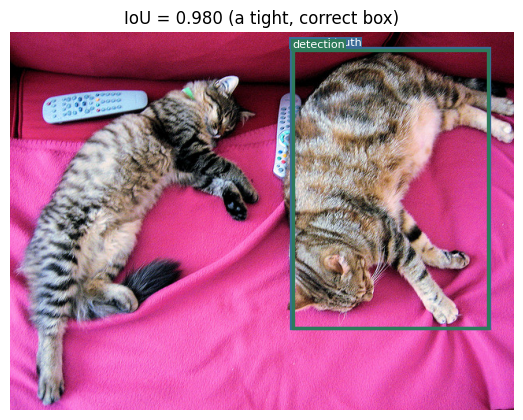

In [13]:
pair, val, name = od._iou_demo_pair(det, image.ground_truth)
print(f"IoU(top '{name}' detection, its ground truth) = {val:.4f}")
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.imshow(image.array)
ax.axis('off')
for bx, c, lab in [(pair[1],'#3A6B96','ground truth'), (pair[0],'#2E7A5A','detection')]:
    ax.add_patch(mpatches.Rectangle((bx[0],bx[1]), bx[2]-bx[0], bx[3]-bx[1], fill=False, edgecolor=c, lw=2.4))
    ax.text(bx[0], bx[1]-3, lab, color='white', fontsize=8, bbox=dict(boxstyle='square,pad=0.1', fc=c, ec='none'))
ax.set_title(f'IoU = {val:.3f} (a tight, correct box)')
plt.show()

## Recap

Detection = **classification + localization**, and it rests on three ideas you just built and verified on a real image: **IoU** measures box overlap (checked against torchvision), **NMS** removes duplicate boxes (checked against torchvision, and it *raises* AP by deleting duplicate false positives), and **AP** is the area under the precision-recall curve (pinned to the hand-verified 11/12 worked example). A real Faster R-CNN found the cats and remotes; its raw output was a flood of overlapping boxes that NMS collapsed to one per object; and mAP@0.5 vs the stricter COCO mAP@[.5:.95] showed how the score tightens with the IoU bar.

See the companion page for the two-stage vs one-stage architecture story (R-CNN → Fast → Faster → YOLO → RetinaNet → DETR), anchors and the class-imbalance problem focal loss solves, the pitfalls, and references — and the sibling chapters on image classification (04, a detector is a classifier over regions), the CNN backbone (05 DL 13), and detection metrics (10).